# F1-RaceIQ-Suite: SVM — Support Vector Machine



## Step 1 — Import Libraries



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load the Cleaned Dataset



In [2]:
df = pd.read_csv('cleaned_f1_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6939 rows, 19 columns


,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


## Step 3 — Identify Categorical and Numerical Columns



In [3]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_columns))

numeric_columns = df.select_dtypes(include=['number']).columns
print("Numeric Columns:", list(numeric_columns))

Categorical Columns: ['Race Name', 'Date', 'Circuit', 'Country', 'Driver', 'Driver Nationality', 'Constructor', 'Status']
Numeric Columns: ['Season', 'Round', 'Latitude', 'Longitude', 'Driver Age', 'Grid Position', 'Race Position', 'Points Earned', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']


## Step 4 — Drop Irrelevant Columns



In [4]:
to_drop = ['Season', 'Round', 'Race Name', 'Date', 'Country',
           'Driver Nationality', 'Driver', 'Points Earned',
           'Latitude', 'Longitude']

df = df.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Circuit', 'Driver Age', 'Constructor', 'Grid Position', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed', 'Status']
Shape after dropping: (6939, 9)


## Step 5 — Encode Categorical Columns



In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

categories_list = [df[col].unique().tolist() for col in categorical_cols]
encoder = OrdinalEncoder(categories=categories_list)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

print("Encoding complete.")
df.head()

Categorical columns to encode: ['Circuit', 'Constructor', 'Status']
Encoding complete.


,Circuit,Driver Age,Constructor,Grid Position,Race Position,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,0.0,44,0.0,1,1,90.239026,-1,70,0.0
1,0.0,39,0.0,4,3,90.239026,-1,70,0.0
2,0.0,46,1.0,6,4,90.239026,-1,68,1.0
3,0.0,45,1.0,9,5,90.239026,-1,68,1.0
4,0.0,36,2.0,13,6,90.239026,-1,67,2.0


## Step 6 — Define the Target Variable



In [6]:
df['Position_Category'] = (df['Race Position'] <= 10).astype(int)
df = df.drop(['Race Position'], axis=1)

print("Target variable distribution:")
print(df['Position_Category'].value_counts())
total = len(df)
points = df['Position_Category'].sum()
print(f"\nClass balance: {points/total*100:.1f}% Points, {(total-points)/total*100:.1f}% No Points")

Target variable distribution:
Position_Category
0    3590
1    3349
Name: count, dtype: int64

Class balance: 48.3% Points, 51.7% No Points


## Step 7 — Feature Engineering (Binary Features)



In [7]:
df['Grid Position Binary'] = (df['Grid Position'] <= 10).astype(int)
df['Driver Age Binary'] = (df['Driver Age'] > 30).astype(int)
df['Laps Completed Binary'] = (df['Laps Completed'] > 50).astype(int)

df = df.drop(['Grid Position', 'Driver Age', 'Laps Completed'], axis=1)
print("Binary features created.")
print("Columns now:", list(df.columns))

Binary features created.
Columns now: ['Circuit', 'Constructor', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Position_Category', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


## Step 8 — Train/Test Split + Feature Scaling



In [8]:
X = df.drop(['Position_Category'], axis=1)
y = df['Position_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]} columns")

Training set: 5551 rows
Test set:     1388 rows
Features:     8 columns


## Step 10 — Polynomial Kernel (degree=3)



In [9]:
# Polynomial C=1
svm_poly_c1 = SVC(kernel='poly', degree=3, C=1.0)
svm_poly_c1.fit(X_train_scaled, y_train)
y_pred_poly_c1 = svm_poly_c1.predict(X_test_scaled)

print("=" * 50)
print("Polynomial Kernel (degree=3) C=1")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_poly_c1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_poly_c1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_poly_c1):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_poly_c1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly_c1, target_names=['No Points', 'Points']))

Polynomial Kernel (degree=3) C=1
Accuracy:  0.8285
Precision: 0.7898
Recall:    0.8712
F1 Score:  0.8285

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.79      0.83       728
      Points       0.79      0.87      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.83      0.83      0.83      1388



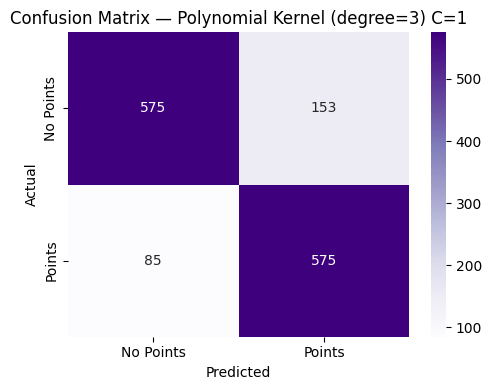

In [10]:
cm_poly_c1 = confusion_matrix(y_test, y_pred_poly_c1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_poly_c1, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Polynomial Kernel (degree=3) C=1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
# Polynomial C=2
svm_poly_c2 = SVC(kernel='poly', degree=3, C=2.0)
svm_poly_c2.fit(X_train_scaled, y_train)
y_pred_poly_c2 = svm_poly_c2.predict(X_test_scaled)

print("=" * 50)
print("Polynomial Kernel (degree=3) C=2")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_poly_c2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_poly_c2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_poly_c2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_poly_c2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly_c2, target_names=['No Points', 'Points']))

Polynomial Kernel (degree=3) C=2
Accuracy:  0.8278
Precision: 0.7903
Recall:    0.8682
F1 Score:  0.8274

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.79      0.83       728
      Points       0.79      0.87      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.83      0.83      0.83      1388



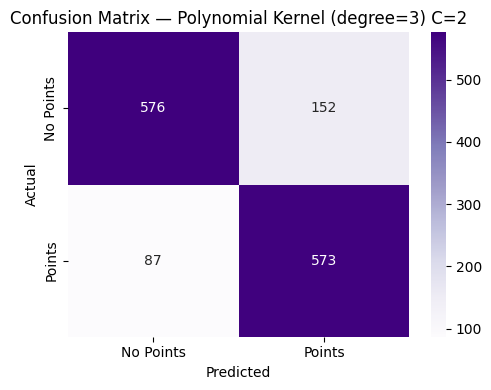

In [12]:
cm_poly_c2 = confusion_matrix(y_test, y_pred_poly_c2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_poly_c2, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Polynomial Kernel (degree=3) C=2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [13]:
# Polynomial C=3
svm_poly_c3 = SVC(kernel='poly', degree=3, C=3.0)
svm_poly_c3.fit(X_train_scaled, y_train)
y_pred_poly_c3 = svm_poly_c3.predict(X_test_scaled)

print("=" * 50)
print("Polynomial Kernel (degree=3) C=3")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_poly_c3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_poly_c3):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_poly_c3):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_poly_c3):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly_c3, target_names=['No Points', 'Points']))

Polynomial Kernel (degree=3) C=3
Accuracy:  0.8264
Precision: 0.7882
Recall:    0.8682
F1 Score:  0.8262

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.79      0.83       728
      Points       0.79      0.87      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.83      0.83      0.83      1388



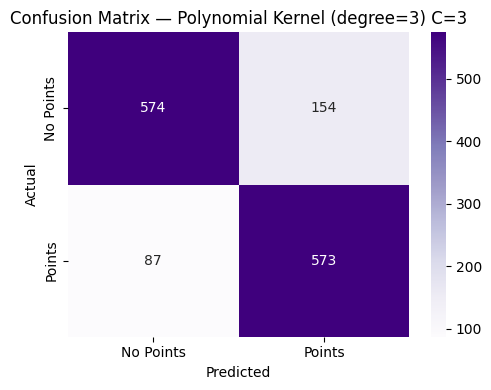

In [14]:
cm_poly_c3 = confusion_matrix(y_test, y_pred_poly_c3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_poly_c3, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Polynomial Kernel (degree=3) C=3')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 11 — RBF Kernel (Radial Basis Function)


In [15]:
# RBF C=1.5
svm_rbf_c1 = SVC(kernel='rbf', gamma='scale', C=1.5)
svm_rbf_c1.fit(X_train_scaled, y_train)
y_pred_rbf_c1 = svm_rbf_c1.predict(X_test_scaled)

print("=" * 50)
print("RBF Kernel C=1.5")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rbf_c1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf_c1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rbf_c1):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rbf_c1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf_c1, target_names=['No Points', 'Points']))

RBF Kernel C=1.5
Accuracy:  0.8329
Precision: 0.8006
Recall:    0.8636
F1 Score:  0.8309

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.80      0.83       728
      Points       0.80      0.86      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.84      0.83      0.83      1388



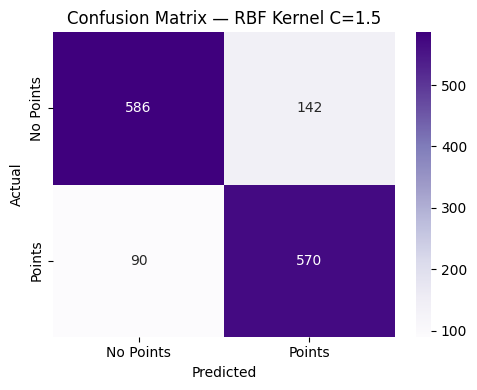

In [16]:
cm_rbf_c1 = confusion_matrix(y_test, y_pred_rbf_c1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rbf_c1, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — RBF Kernel C=1.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [17]:
# RBF C=2.5
svm_rbf_c2 = SVC(kernel='rbf', gamma='scale', C=2.5)
svm_rbf_c2.fit(X_train_scaled, y_train)
y_pred_rbf_c2 = svm_rbf_c2.predict(X_test_scaled)

print("=" * 50)
print("RBF Kernel C=2.5")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rbf_c2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf_c2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rbf_c2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rbf_c2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf_c2, target_names=['No Points', 'Points']))

RBF Kernel C=2.5
Accuracy:  0.8372
Precision: 0.8056
Recall:    0.8667
F1 Score:  0.8350

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.81      0.84       728
      Points       0.81      0.87      0.84       660

    accuracy                           0.84      1388
   macro avg       0.84      0.84      0.84      1388
weighted avg       0.84      0.84      0.84      1388



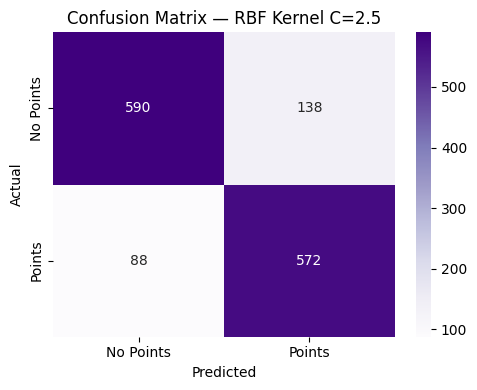

In [18]:
cm_rbf_c2 = confusion_matrix(y_test, y_pred_rbf_c2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rbf_c2, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — RBF Kernel C=2.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [19]:
# RBF C=3.5
svm_rbf_c3 = SVC(kernel='rbf', gamma='scale', C=3.5)
svm_rbf_c3.fit(X_train_scaled, y_train)
y_pred_rbf_c3 = svm_rbf_c3.predict(X_test_scaled)

print("=" * 50)
print("RBF Kernel C=3.5")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rbf_c3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf_c3):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rbf_c3):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rbf_c3):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf_c3, target_names=['No Points', 'Points']))

RBF Kernel C=3.5
Accuracy:  0.8408
Precision: 0.8061
Recall:    0.8758
F1 Score:  0.8395

Classification Report:
              precision    recall  f1-score   support

   No Points       0.88      0.81      0.84       728
      Points       0.81      0.88      0.84       660

    accuracy                           0.84      1388
   macro avg       0.84      0.84      0.84      1388
weighted avg       0.84      0.84      0.84      1388



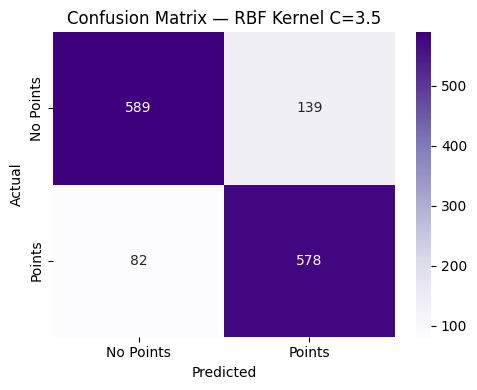

In [20]:
cm_rbf_c3 = confusion_matrix(y_test, y_pred_rbf_c3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rbf_c3, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — RBF Kernel C=3.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 12 — Linear Kernel



In [21]:
# Linear C=0.02
svm_linear_c1 = SVC(kernel='linear', C=0.02)
svm_linear_c1.fit(X_train_scaled, y_train)
y_pred_linear_c1 = svm_linear_c1.predict(X_test_scaled)

print("=" * 50)
print("Linear Kernel C=0.02")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_linear_c1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_linear_c1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_linear_c1):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_linear_c1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear_c1, target_names=['No Points', 'Points']))

Linear Kernel C=0.02
Accuracy:  0.8127
Precision: 0.8058
Recall:    0.7985
F1 Score:  0.8021

Classification Report:
              precision    recall  f1-score   support

   No Points       0.82      0.83      0.82       728
      Points       0.81      0.80      0.80       660

    accuracy                           0.81      1388
   macro avg       0.81      0.81      0.81      1388
weighted avg       0.81      0.81      0.81      1388



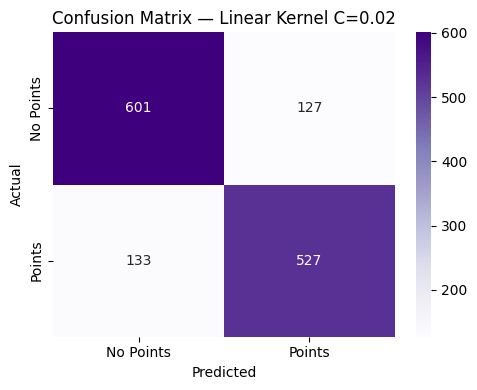

In [22]:
cm_linear_c1 = confusion_matrix(y_test, y_pred_linear_c1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_linear_c1, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Linear Kernel C=0.02')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
# Linear C=0.5
svm_linear_c2 = SVC(kernel='linear', C=0.5)
svm_linear_c2.fit(X_train_scaled, y_train)
y_pred_linear_c2 = svm_linear_c2.predict(X_test_scaled)

print("=" * 50)
print("Linear Kernel C=0.5")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_linear_c2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_linear_c2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_linear_c2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_linear_c2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear_c2, target_names=['No Points', 'Points']))

Linear Kernel C=0.5
Accuracy:  0.8141
Precision: 0.8102
Recall:    0.7955
F1 Score:  0.8028

Classification Report:
              precision    recall  f1-score   support

   No Points       0.82      0.83      0.82       728
      Points       0.81      0.80      0.80       660

    accuracy                           0.81      1388
   macro avg       0.81      0.81      0.81      1388
weighted avg       0.81      0.81      0.81      1388



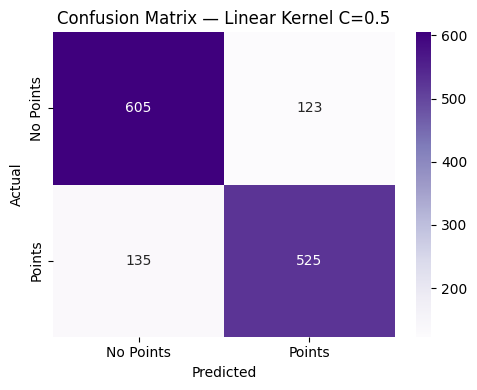

In [24]:
cm_linear_c2 = confusion_matrix(y_test, y_pred_linear_c2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_linear_c2, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Linear Kernel C=0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [25]:
# Linear C=3.0
svm_linear_c3 = SVC(kernel='linear', C=3.0)
svm_linear_c3.fit(X_train_scaled, y_train)
y_pred_linear_c3 = svm_linear_c3.predict(X_test_scaled)

print("=" * 50)
print("Linear Kernel C=3.0")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_linear_c3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_linear_c3):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_linear_c3):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_linear_c3):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear_c3, target_names=['No Points', 'Points']))

Linear Kernel C=3.0
Accuracy:  0.8141
Precision: 0.8102
Recall:    0.7955
F1 Score:  0.8028

Classification Report:
              precision    recall  f1-score   support

   No Points       0.82      0.83      0.82       728
      Points       0.81      0.80      0.80       660

    accuracy                           0.81      1388
   macro avg       0.81      0.81      0.81      1388
weighted avg       0.81      0.81      0.81      1388



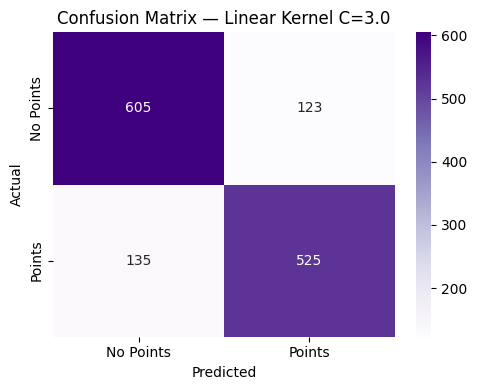

In [26]:
cm_linear_c3 = confusion_matrix(y_test, y_pred_linear_c3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_linear_c3, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.title('Confusion Matrix — Linear Kernel C=3.0')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 13 — Decision Boundary Visualisation


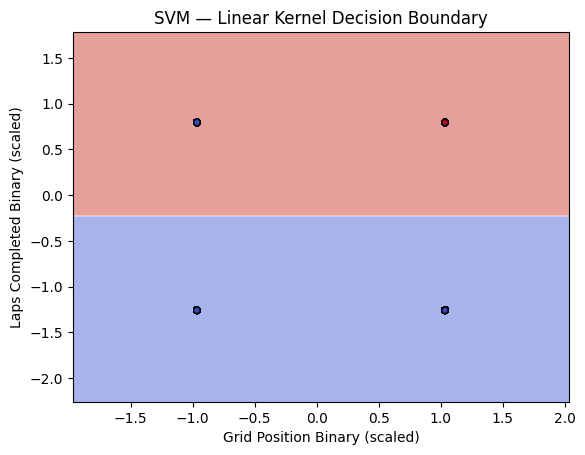

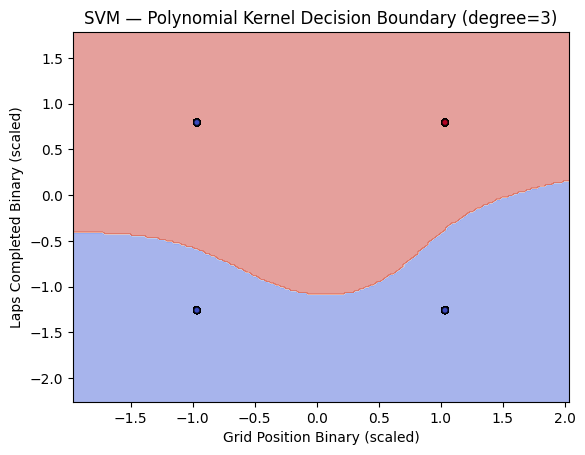

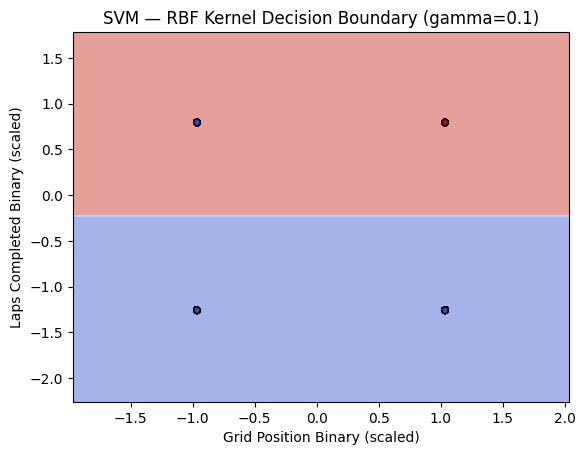

In [27]:
# Prepare 2D data for visualisation
df_viz = df[['Grid Position Binary', 'Laps Completed Binary', 'Position_Category']].copy()

X_viz = df_viz[['Grid Position Binary', 'Laps Completed Binary']].values
y_viz = df_viz['Position_Category'].values

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

def plot_decision_boundary(clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20,
                edgecolors='k', cmap=plt.cm.coolwarm, alpha=0.6)
    plt.title(title)
    plt.xlabel('Grid Position Binary (scaled)')
    plt.ylabel('Laps Completed Binary (scaled)')
    plt.show()

# Linear Kernel
svm_linear_viz = SVC(kernel='linear', C=1)
svm_linear_viz.fit(X_viz_scaled, y_viz)
plot_decision_boundary(svm_linear_viz, X_viz_scaled, y_viz,
                       "SVM — Linear Kernel Decision Boundary")

# Polynomial Kernel
svm_poly_viz = SVC(kernel='poly', degree=3, C=1)
svm_poly_viz.fit(X_viz_scaled, y_viz)
plot_decision_boundary(svm_poly_viz, X_viz_scaled, y_viz,
                       "SVM — Polynomial Kernel Decision Boundary (degree=3)")

# RBF Kernel
svm_rbf_viz = SVC(kernel='rbf', gamma=0.1, C=1)
svm_rbf_viz.fit(X_viz_scaled, y_viz)
plot_decision_boundary(svm_rbf_viz, X_viz_scaled, y_viz,
                       "SVM — RBF Kernel Decision Boundary (gamma=0.1)")

## Step 14 — Full Model Comparison (All 9 SVM Models)



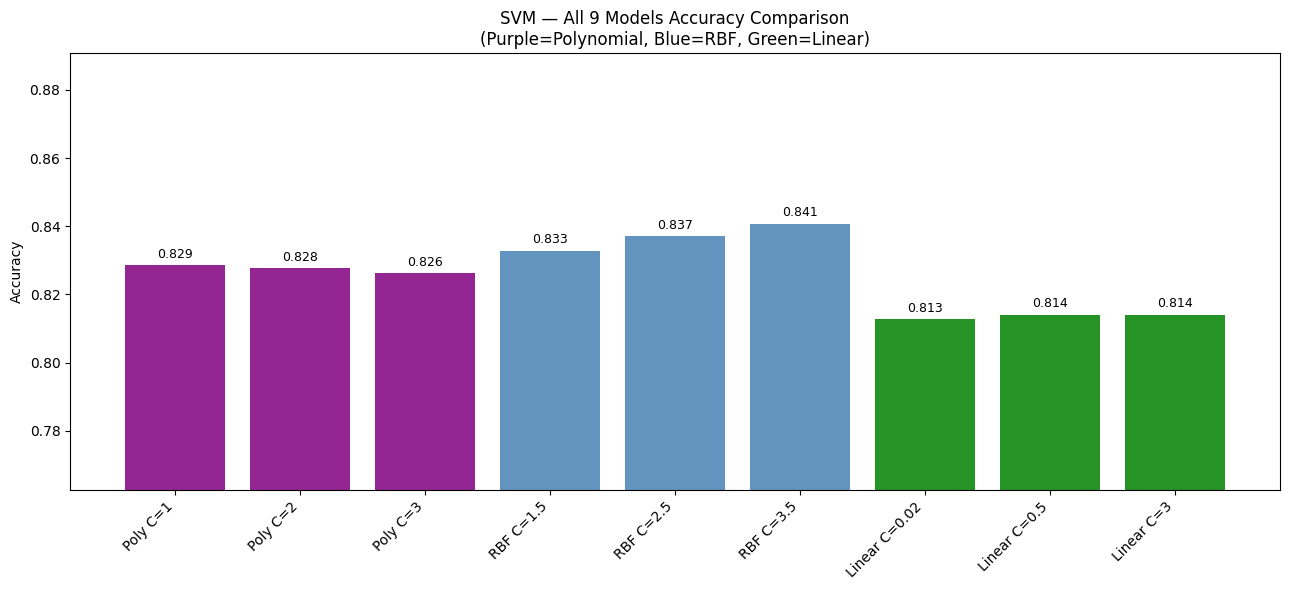

        Model  Accuracy
     Poly C=1  0.828530
     Poly C=2  0.827810
     Poly C=3  0.826369
    RBF C=1.5  0.832853
    RBF C=2.5  0.837176
    RBF C=3.5  0.840778
Linear C=0.02  0.812680
 Linear C=0.5  0.814121
   Linear C=3  0.814121


In [28]:
model_names = [
    'Poly C=1', 'Poly C=2', 'Poly C=3',
    'RBF C=1.5', 'RBF C=2.5', 'RBF C=3.5',
    'Linear C=0.02', 'Linear C=0.5', 'Linear C=3'
]

accuracies = [
    accuracy_score(y_test, y_pred_poly_c1),
    accuracy_score(y_test, y_pred_poly_c2),
    accuracy_score(y_test, y_pred_poly_c3),
    accuracy_score(y_test, y_pred_rbf_c1),
    accuracy_score(y_test, y_pred_rbf_c2),
    accuracy_score(y_test, y_pred_rbf_c3),
    accuracy_score(y_test, y_pred_linear_c1),
    accuracy_score(y_test, y_pred_linear_c2),
    accuracy_score(y_test, y_pred_linear_c3)
]

colors = ['purple']*3 + ['steelblue']*3 + ['green']*3

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(model_names, accuracies, color=colors, alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('SVM — All 9 Models Accuracy Comparison\n(Purple=Polynomial, Blue=RBF, Green=Linear)')
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])
plt.tight_layout()
plt.show()

# Summary table
results = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})
print(results.to_string(index=False))